# Logistic Regression in depth

## 1. Libs and config

In [94]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    recall_score,
    precision_score,
    confusion_matrix,
    classification_report,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    RocCurveDisplay,
)

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

import sys
import os

sys.path.append(os.path.abspath(".."))
print(os.getcwd())

/Users/luisfernandocorcueraleon/Desktop/code/Credit-Score-Classification/experiments


# Data

In [10]:
df = pd.read_csv("../data/df_cleaned.csv")

In [21]:
target = "Credit_Score_binomial"
categorical_columns = (
    df.select_dtypes(include=["object"]).columns.drop("Customer_ID").tolist()
)
numerical_columns = (
    df.select_dtypes(include=["int64", "float32"])
    .columns.drop([target, "num_month"])
    .tolist()
)
final_features = numerical_columns + categorical_columns

# Prepare data

In [26]:
X = df[final_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.25, random_state=42
)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(75000, 16)
(75000,)
(25000, 16)
(25000,)


In [30]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Credit_Score_binomial
0    0.710013
1    0.289987
Name: proportion, dtype: float64
Credit_Score_binomial
0    0.71004
1    0.28996
Name: proportion, dtype: float64


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
    ]
)

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Modelling

In [61]:
lc_model = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(class_weight="balanced")),
    ]
)

In [62]:
lc_model.fit(X_train, y_train)

y_pred = lc_model.predict(X_test)
y_proba = lc_model.predict_proba(X_test)[:, 1]

results_1 = classification_report(y_test, y_pred)
print(results_1)

              precision    recall  f1-score   support

           0       0.85      0.79      0.81     17751
           1       0.55      0.65      0.60      7249

    accuracy                           0.75     25000
   macro avg       0.70      0.72      0.71     25000
weighted avg       0.76      0.75      0.75     25000



In [86]:
preprocessor_fitted = lc_model.named_steps["preprocessor"]
features_names = preprocessor_fitted.get_feature_names_out()
logistic_model = lc_model.named_steps["classifier"]
coef_report = []
for col, coef in zip(features_names, logistic_model.coef_[0]):
    coef_report.append([col, coef])

coef_report = pd.DataFrame(coef_report, columns=["feature", "coef"])
coef_report.sort_values(by="coef", ascending=False, key=lambda x: np.abs(x))

,feature,coef
36,cat__Payment_of_Min_Amount_No,-0.807255
29,cat__Credit_Mix_Standard,-0.748080
37,cat__Payment_of_Min_Amount_Yes,0.683487
28,cat__Credit_Mix_Good,0.654302
2,num__Delay_from_due_date,0.506428
30,cat__Payment_Behaviour_High_spent_Large_value_...,-0.219308
35,cat__Payment_Behaviour_Low_spent_Small_value_p...,0.217797
22,cat__Occupation_Media_Manager,-0.146306
15,cat__Occupation_Doctor,-0.136231
31,cat__Payment_Behaviour_High_spent_Medium_value...,-0.121844


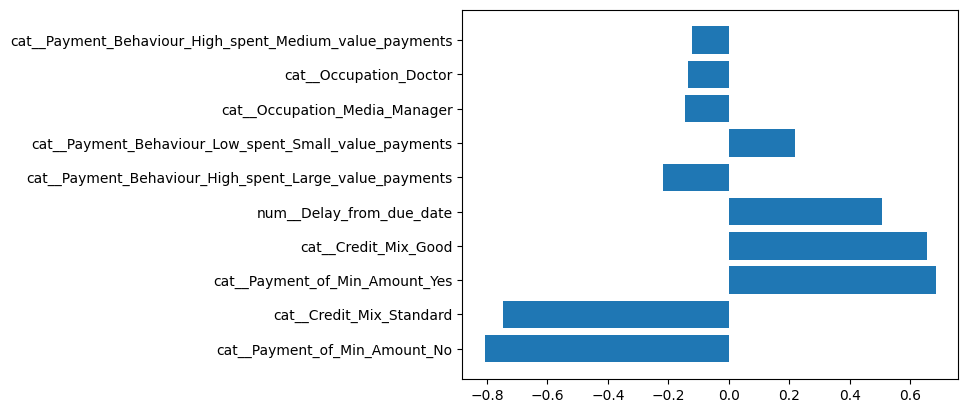

In [ ]:
top_10 = coef_report.sort_values(
    by="coef", ascending=False, key=lambda x: np.abs(x)
).head(10)

plt.barh(top_10["feature"], top_10["coef"])
plt.show()

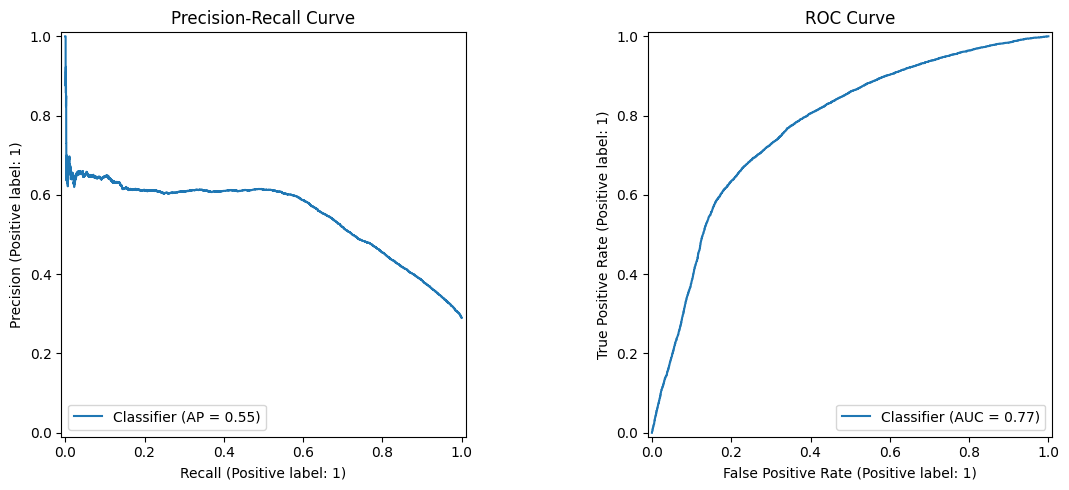

In [99]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=ax[0])
ax[0].set_title("Precision-Recall Curve")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax[1])
ax[1].set_title("ROC Curve")

plt.tight_layout()
plt.show()